## LOAD DATA

In [ ]:
import kagglehub
import os
import pandas as pd

# 1. ดาวน์โหลด Dataset ผ่าน kagglehub (ตามที่คุณเขียนมา)
print("Downloading dataset...")
path = kagglehub.dataset_download("ziya07/smart-manufacturing-iot-cloud-monitoring-dataset")
print(f"✅ โหลดสำเร็จ! ไฟล์ถูกเก็บไว้ที่: {path}")

# 2. เช็คดูว่าในโฟลเดอร์ที่โหลดมา มีไฟล์อะไรบ้าง
files_in_dir = os.listdir(path)
print(f"📂 ไฟล์ที่พบในโฟลเดอร์: {files_in_dir}")

# 3. ค้นหาไฟล์นามสกุล .csv และสร้าง Path เต็ม
# (ใช้ List Comprehension ดึงไฟล์ csv ตัวแรกออกมา)
csv_filename = [f for f in files_in_dir if f.endswith('.csv')][0]
full_file_path = os.path.join(path, csv_filename)

print(f"🚀 กำลังโหลดไฟล์: {csv_filename} เข้าสู่ Pandas...")

# 4. อ่านไฟล์ CSV เข้า DataFrame
df = pd.read_csv(full_file_path)

# 5. แสดงผล 5 บรรทัดแรกเพื่อเช็คความเรียบร้อย
display(df.head())

# (แถม) ดูข้อมูลเบื้องต้นของ Dataset
print("\n--- สรุปข้อมูล (Data Info) ---")
df.info()

100%|██████████| 1.83M/1.83M [00:01<00:00, 1.34MB/s]

Extracting files...


✅ โหลดสำเร็จ! ไฟล์ถูกเก็บไว้ที่: /root/.cache/kagglehub/datasets/ziya07/smart-manufacturing-iot-cloud-monitoring-dataset/versions/1
📂 ไฟล์ที่พบในโฟลเดอร์: ['smart_manufacturing_data.csv']
🚀 กำลังโหลดไฟล์: smart_manufacturing_data.csv เข้าสู่ Pandas...


,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,Normal,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,Normal,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,Normal,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,Normal,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,Vibration Issue,0.0,1



--- สรุปข้อมูล (Data Info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   timestamp                 100000 non-null  object 
 1   machine_id                100000 non-null  int64  
 2   temperature               100000 non-null  float64
 3   vibration                 100000 non-null  float64
 4   humidity                  100000 non-null  float64
 5   pressure                  100000 non-null  float64
 6   energy_consumption        100000 non-null  float64
 7   machine_status            100000 non-null  int64  
 8   anomaly_flag              100000 non-null  int64  
 9   predicted_remaining_life  100000 non-null  int64  
 10  failure_type              100000 non-null  object 
 11  downtime_risk             100000 non-null  float64
 12  maintenance_required      100000 non-null  int64  
dtypes: float64(6)

## DATA CLEAN

In [ ]:
import pandas as pd
import os
import kagglehub
from sklearn.preprocessing import StandardScaler

# 1. ให้ kagglehub ดึง Path ของไฟล์ที่โหลดไว้แล้วมาให้
path = kagglehub.dataset_download("ziya07/smart-manufacturing-iot-cloud-monitoring-dataset")

# ค้นหาไฟล์ .csv ในโฟลเดอร์นั้น และสร้าง Path แบบเต็ม
files_in_dir = os.listdir(path)
csv_filename = [f for f in files_in_dir if f.endswith('.csv')][0]
full_file_path = os.path.join(path, csv_filename)

print(f"📂 กำลังอ่านไฟล์จาก: {full_file_path}")

# 2. โหลดข้อมูลจาก Path เต็ม
df = pd.read_csv(full_file_path)

# 3. เลือกรหัสเครื่องจักร (Machine ID = 50 ตามที่คุณกำหนด)
machine_id_target = 50
df_machine = df[df['machine_id'] == machine_id_target].copy()

# 4. กำหนดตัวแปร Feature (เซ็นเซอร์) และ เฉลย (Target)
sensor_columns = ['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption']
X_raw = df_machine[sensor_columns]
y_target = df_machine['maintenance_required']

# 5. ทำ Data Scaling (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 6. เช็คความพร้อมของข้อมูล
print(f"\n✅ เตรียมข้อมูลของ Machine ID: {machine_id_target} เรียบร้อย!")
print(f"📊 จำนวนข้อมูลที่พร้อม Train: {X_scaled.shape[0]} records")
print("\nตัวอย่างข้อมูลที่ถูกสเกลแล้ว (5 แถวแรก):")
print(X_scaled[:5])

Using Colab cache for faster access to the 'smart-manufacturing-iot-cloud-monitoring-dataset' dataset.
📂 กำลังอ่านไฟล์จาก: /kaggle/input/smart-manufacturing-iot-cloud-monitoring-dataset/smart_manufacturing_data.csv

✅ เตรียมข้อมูลของ Machine ID: 50 เรียบร้อย!
📊 จำนวนข้อมูลที่พร้อม Train: 1912 records

ตัวอย่างข้อมูลที่ถูกสเกลแล้ว (5 แถวแรก):
[[-0.11151295 -0.6785652  -0.50603772  0.47115582 -1.21026046]
 [-0.36211911 -0.24873246 -1.03244078 -0.61077464 -1.19474128]
 [ 0.10567905  1.21551087 -1.45314599  0.35863505 -0.06184132]
 [ 0.53809751  0.45158694  0.53286079 -1.52825167 -0.66708925]
 [ 0.01231597  0.91087863 -1.31615603 -0.61943008  0.48132989]]


## TRAIN AND EVALUATE

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.decomposition import PCA

def evaluate_extrinsic_clustering(model_name, cluster_labels, y_true, X_raw):
    """
    ฟังก์ชันประเมินผล Extrinsic Metrics และหา Failure Rate ของแต่ละกลุ่ม
    """
    print(f"=== 📊 ผลการประเมินโมเดล: {model_name} ===")

    # 1. คำนวณ Standard Extrinsic Metrics
    homogeneity = metrics.homogeneity_score(y_true, cluster_labels)
    completeness = metrics.completeness_score(y_true, cluster_labels)
    v_measure = metrics.v_measure_score(y_true, cluster_labels)
    ari = metrics.adjusted_rand_score(y_true, cluster_labels)

    print(f"Homogeneity  : {homogeneity:.4f} (ยิ่งใกล้ 1 ยิ่งดี กลุ่มมีความบริสุทธิ์)")
    print(f"Completeness : {completeness:.4f} (ยิ่งใกล้ 1 ยิ่งดี ข้อมูลไม่แตกกระจาย)")
    print(f"V-Measure    : {v_measure:.4f} (คะแนนภาพรวม)")
    print(f"Adjusted Rand: {ari:.4f} (ความแม่นยำเทียบกับเฉลย หักลบการเดาสุ่ม)")

    # 2. คำนวณอัตราการพัง (Failure Rate) เพื่อหา Golden Zone
    df_eval = X_raw.copy()
    df_eval['Cluster'] = cluster_labels
    df_eval['Target'] = y_true.values

    summary = df_eval.groupby('Cluster').agg(
        Total_Samples=('Target', 'count'),
        Failures=('Target', 'sum')
    )
    summary['Failure_Rate (%)'] = (summary['Failures'] / summary['Total_Samples']) * 100

    print("\n--- 🔍 วิเคราะห์หา Golden Zone (กลุ่มที่มีการพังน้อยที่สุด) ---")
    print(summary.sort_values('Failure_Rate (%)'))

    return df_eval

def visualize_clusters_pca(df_eval, model_name):
    """
    ฟังก์ชันวาดกราฟ 2D โดยยุบรวมเซ็นเซอร์ 5 ตัวด้วย PCA
    """
    # ใช้เซ็นเซอร์ 5 ตัวมาทำ PCA
    features = ['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption']
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(df_eval[features])

    df_eval['PCA1'] = pca_result[:, 0]
    df_eval['PCA2'] = pca_result[:, 1]

    plt.figure(figsize=(10, 6))

    # พล็อตจุดทั้งหมดตาม Cluster
    sns.scatterplot(
        data=df_eval, x='PCA1', y='PCA2',
        hue='Cluster', palette='Set2', alpha=0.6, s=50
    )

    # พล็อตทับจุดที่มี Target = 1 (พัง) ด้วยกากบาทสีแดง
    failures = df_eval[df_eval['Target'] == 1]
    plt.scatter(failures['PCA1'], failures['PCA2'],
                color='red', marker='x', s=100, label='Failure (Target=1)')

    plt.title(f"Cluster Visualization ({model_name}) with Failure Points")
    plt.legend()
    plt.show()

## K-MEANS

=== 📊 ผลการประเมินโมเดล: K-Means (k=3) ===
Homogeneity  : 0.0054 (ยิ่งใกล้ 1 ยิ่งดี กลุ่มมีความบริสุทธิ์)
Completeness : 0.0026 (ยิ่งใกล้ 1 ยิ่งดี ข้อมูลไม่แตกกระจาย)
V-Measure    : 0.0035 (คะแนนภาพรวม)
Adjusted Rand: 0.0047 (ความแม่นยำเทียบกับเฉลย หักลบการเดาสุ่ม)

--- 🔍 วิเคราะห์หา Golden Zone (กลุ่มที่มีการพังน้อยที่สุด) ---
         Total_Samples  Failures  Failure_Rate (%)
Cluster                                           
2                  689       124         17.997097
0                  637       136         21.350078
1                  586       150         25.597270


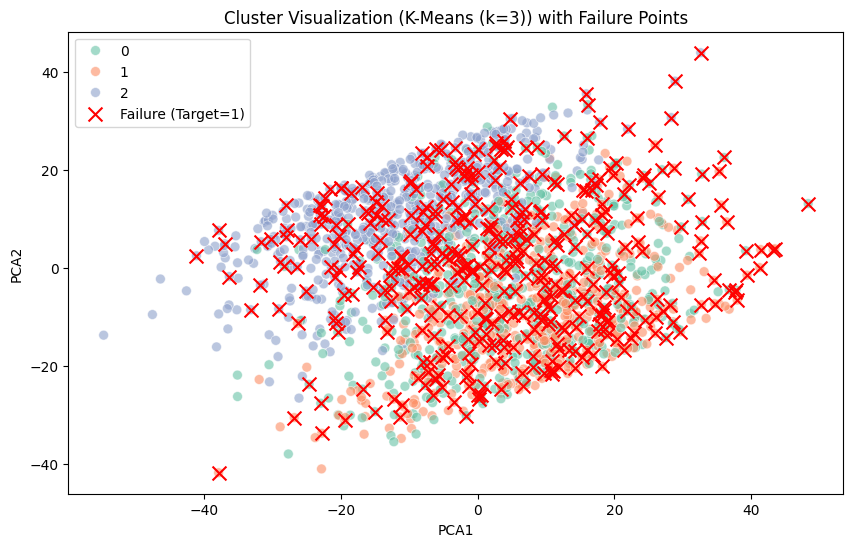

In [ ]:
# 1. กำหนดและ Train โมเดล K-Means
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
# ข้อควรระวัง: K-Means ต้องใช้ X_scaled เท่านั้น
kmeans_labels = kmeans_model.fit_predict(X_scaled)

# 2. ประเมินผล Metrics
df_result = evaluate_extrinsic_clustering("K-Means (k=3)", kmeans_labels, y_target, X_raw)

# 3. วาดกราฟ Visualize
visualize_clusters_pca(df_result, "K-Means (k=3)")

## DBSCANS

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn import metrics

# 1. กำหนดช่วงของพารามิเตอร์ที่จะทำ Grid Search
eps_values = np.arange(0.5, 2.0, 0.1) # ลองตั้งแต่ 0.5 ถึง 1.9 ทีละ 0.1
min_samples_values = [5, 10, 15, 20, 25]

# 2. สร้างลิสต์สำหรับเก็บผลลัพธ์
grid_results = []

print("🚀 กำลังรัน Grid Search สำหรับ DBSCAN...")

# 3. วนลูปเพื่อทดสอบทุกๆ การจับคู่ (Grid Search Loop)
for eps in eps_values:
    for min_samples in min_samples_values:
        # กำหนดโมเดลและ Train
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        # คำนวณจำนวนกลุ่ม (ไม่นับ -1) และจำนวน Noise
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        # เราจะพิจารณาเฉพาะการตั้งค่าที่แบ่งกลุ่มได้ 1 กลุ่มขึ้นไป และมี Noise ไม่เยอะจนเกินไป
        if n_clusters > 0 and n_noise < (len(X_scaled) * 0.5):
            # คำนวณค่าชี้วัดความแม่นยำเทียบกับเฉลย (ARI)
            ari = metrics.adjusted_rand_score(y_target, labels)
            homogeneity = metrics.homogeneity_score(y_target, labels)

            # บันทึกผลลัพธ์
            grid_results.append({
                'eps': round(eps, 1),
                'min_samples': min_samples,
                'Clusters': n_clusters,
                'Noise_Points': n_noise,
                'Homogeneity': homogeneity,
                'ARI': ari
            })

# 4. แปลงผลลัพธ์เป็น DataFrame เพื่อให้ดูง่ายๆ
df_grid = pd.DataFrame(grid_results)

# 5. เรียงลำดับตามค่า ARI จากมากไปน้อย (หาค่าที่แยกกลุ่มพัง/ปกติได้ดีที่สุด)
if not df_grid.empty:
    df_grid_sorted = df_grid.sort_values(by='ARI', ascending=False).reset_index(drop=True)
    print("\n✅ รันเสร็จสิ้น! นี่คือ Top 10 พารามิเตอร์ที่ดีที่สุด:")
    display(df_grid_sorted.head(10))
else:
    print("❌ ไม่พบพารามิเตอร์ที่เหมาะสมในกรอบที่กำหนด ลองขยายช่วง eps ดูครับ")

🚀 กำลังรัน Grid Search สำหรับ DBSCAN...

✅ รันเสร็จสิ้น! นี่คือ Top 10 พารามิเตอร์ที่ดีที่สุด:


,eps,min_samples,Clusters,Noise_Points,Homogeneity,ARI
0,1.0,10,1,230,0.066876,0.193808
1,1.1,25,1,339,0.067901,0.188918
2,1.1,20,1,255,0.061543,0.184168
3,1.0,15,1,393,0.059788,0.167238
4,1.1,15,1,173,0.054036,0.166893
5,0.9,5,3,196,0.057240,0.165264
6,0.8,5,5,439,0.057315,0.149306
7,0.9,10,1,484,0.057618,0.147704
8,1.2,25,1,156,0.040563,0.139074
9,1.0,20,1,577,0.063144,0.136735


✅ DBSCAN พบกลุ่ม (Cluster) ทั้งหมด: 3 กลุ่ม
🚨 จุดที่ถูกคัดทิ้งเป็น Noise (Cluster -1): 196 จุด
----------------------------------------
=== 📊 ผลการประเมินโมเดล: DBSCAN (eps=1.2, min=15) ===
Homogeneity  : 0.0572 (ยิ่งใกล้ 1 ยิ่งดี กลุ่มมีความบริสุทธิ์)
Completeness : 0.0781 (ยิ่งใกล้ 1 ยิ่งดี ข้อมูลไม่แตกกระจาย)
V-Measure    : 0.0661 (คะแนนภาพรวม)
Adjusted Rand: 0.1653 (ความแม่นยำเทียบกับเฉลย หักลบการเดาสุ่ม)

--- 🔍 วิเคราะห์หา Golden Zone (กลุ่มที่มีการพังน้อยที่สุด) ---
         Total_Samples  Failures  Failure_Rate (%)
Cluster                                           
 0                1701       303         17.813051
-1                 196        95         48.469388
 2                   6         3         50.000000
 1                   9         9        100.000000


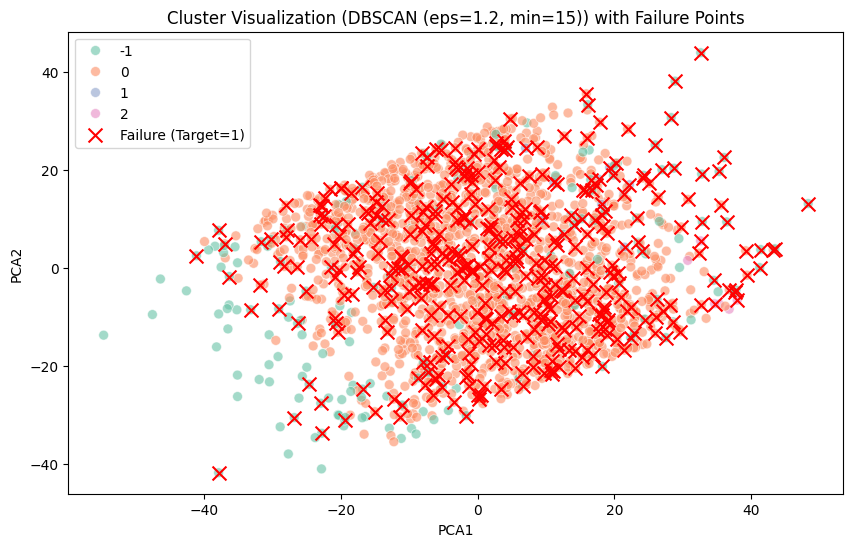

In [ ]:
from sklearn.cluster import DBSCAN

# 1. กำหนดและ Train โมเดล DBSCAN
# (สามารถลองปรับค่า eps เพิ่ม/ลดได้ หากกลุ่มที่ได้ยังไม่พอดี)
dbscan_model = DBSCAN(eps=0.9, min_samples=5)
dbscan_labels = dbscan_model.fit_predict(X_scaled)

# 2. เช็คจำนวนกลุ่มที่โมเดลหาเจอ
n_clusters_ = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_ = list(dbscan_labels).count(-1)

print(f"✅ DBSCAN พบกลุ่ม (Cluster) ทั้งหมด: {n_clusters_} กลุ่ม")
print(f"🚨 จุดที่ถูกคัดทิ้งเป็น Noise (Cluster -1): {n_noise_} จุด")
print("-" * 40)

# 3. เรียกใช้ฟังก์ชันประเมินผลของคุณได้เลย!
df_dbscan_result = evaluate_extrinsic_clustering(
    "DBSCAN (eps=1.2, min=15)",
    dbscan_labels,
    y_target,
    X_raw
)

# 4. เรียกใช้ฟังก์ชันวาดกราฟของคุณ
visualize_clusters_pca(df_dbscan_result, "DBSCAN (eps=1.2, min=15)")

In [ ]:
# 1. ดึงข้อมูลเฉพาะกลุ่มที่เป็น Golden Zone (Cluster 0)
# เปลี่ยนมาใช้ตัวแปร df_dbscan_result ที่คุณมีอยู่
golden_zone_data = df_dbscan_result[df_dbscan_result['Cluster'] == 0]

# 2. ดึงข้อมูลกลุ่มโซนมรณะ (Cluster 1) มาดูไว้เตือนภัย
death_zone_data = df_dbscan_result[df_dbscan_result['Cluster'] == 1]

# 3. เลือกคอลัมน์เซ็นเซอร์ที่เราต้องการดูค่าขอบเขต
sensor_cols = ['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption']

print("🌟 ขอบเขตการทำงานของ Golden Zone (Cluster 0) 🌟")
print("ถ้าควบคุมเครื่องจักรให้อยู่ในสภาวะนี้ได้ จะทำงานได้เสถียรที่สุด")
display(golden_zone_data[sensor_cols].agg(['min', 'mean', 'max']).T.round(2))

print("\n💀 ขอบเขตของโซนมรณะ (Cluster 1) 💀")
print("ห้ามปล่อยให้ค่าเซ็นเซอร์เข้าใกล้ตัวเลขเหล่านี้เด็ดขาด (พัง 100%)")
display(death_zone_data[sensor_cols].agg(['min', 'mean', 'max']).T.round(2))

🌟 ขอบเขตการทำงานของ Golden Zone (Cluster 0) 🌟
ถ้าควบคุมเครื่องจักรให้อยู่ในสภาวะนี้ได้ จะทำงานได้เสถียรที่สุด


,min,mean,max
temperature,49.69,74.93,101.46
vibration,17.07,50.80,90.28
humidity,30.03,55.37,79.90
pressure,1.00,3.04,5.00
energy_consumption,0.50,2.74,5.00



💀 ขอบเขตของโซนมรณะ (Cluster 1) 💀
ห้ามปล่อยให้ค่าเซ็นเซอร์เข้าใกล้ตัวเลขเหล่านี้เด็ดขาด (พัง 100%)


,min,mean,max
temperature,91.02,95.73,99.96
vibration,62.83,71.77,77.59
humidity,49.53,61.91,74.36
pressure,2.75,3.98,4.92
energy_consumption,1.67,2.67,3.63


## T-SNE AND DBSCAN

🚀 กำลังรัน DBSCAN บนพื้นที่ของ t-SNE...
✅ DBSCAN บน t-SNE พบ: 1 กลุ่ม
🚨 จุดที่เป็น Noise (Cluster -1): 2 จุด
----------------------------------------
=== 📊 ผลการประเมินโมเดล: t-SNE + DBSCAN ===
Homogeneity  : 0.0005 (ยิ่งใกล้ 1 ยิ่งดี กลุ่มมีความบริสุทธิ์)
Completeness : 0.0307 (ยิ่งใกล้ 1 ยิ่งดี ข้อมูลไม่แตกกระจาย)
V-Measure    : 0.0010 (คะแนนภาพรวม)
Adjusted Rand: -0.0015 (ความแม่นยำเทียบกับเฉลย หักลบการเดาสุ่ม)

--- 🔍 วิเคราะห์หา Golden Zone (กลุ่มที่มีการพังน้อยที่สุด) ---
         Total_Samples  Failures  Failure_Rate (%)
Cluster                                           
-1                   2         0          0.000000
 0                1910       410         21.465969


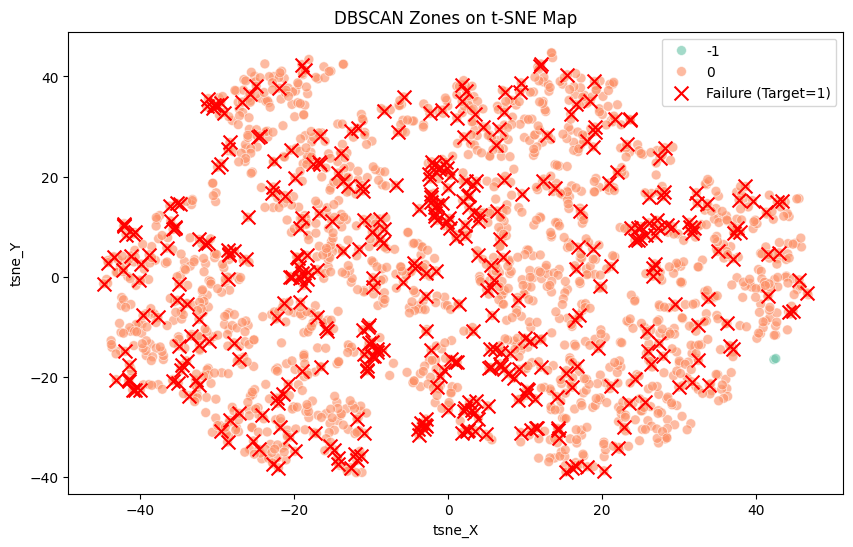

In [ ]:
from sklearn.cluster import DBSCAN

print("🚀 กำลังรัน DBSCAN บนพื้นที่ของ t-SNE...")

# 1. กำหนด DBSCAN (ปรับ eps ให้ใหญ่ขึ้น เพราะสเกลพิกัด t-SNE กว้างกว่าปกติ)
# คุณอาจจะต้องลองเปลี่ยน eps เป็น 2.0, 4.0, หรือ 6.0 ดูครับถ้าระยะมันยังไม่พอดี
dbscan_on_tsne = DBSCAN(eps=4.5, min_samples=5)

# ใช้ X_tsne (พิกัด 2 มิติ) ในการ Train แทน X_scaled
tsne_dbscan_labels = dbscan_on_tsne.fit_predict(X_tsne)

# 2. เช็คจำนวนกลุ่มและ Noise
n_clusters_tsne = len(set(tsne_dbscan_labels)) - (1 if -1 in tsne_dbscan_labels else 0)
n_noise_tsne = list(tsne_dbscan_labels).count(-1)

print(f"✅ DBSCAN บน t-SNE พบ: {n_clusters_tsne} กลุ่ม")
print(f"🚨 จุดที่เป็น Noise (Cluster -1): {n_noise_tsne} จุด")
print("-" * 40)

# 3. ประเมินผลด้วยฟังก์ชันเดิมของคุณ
df_tsne_dbscan_result = evaluate_extrinsic_clustering(
    "t-SNE + DBSCAN",
    tsne_dbscan_labels,
    y_target,
    X_raw
)

# 4. วาดกราฟ Visualize ผลลัพธ์
df_tsne_dbscan_result['tsne_X'] = X_tsne[:, 0]
df_tsne_dbscan_result['tsne_Y'] = X_tsne[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_tsne_dbscan_result, x='tsne_X', y='tsne_Y',
    hue='Cluster', palette='Set2', alpha=0.6, s=50
)

# พล็อตจุด Target=1 (เครื่องพัง) เป็นกากบาทสีแดง
failures = df_tsne_dbscan_result[df_tsne_dbscan_result['Target'] == 1]
plt.scatter(failures['tsne_X'], failures['tsne_Y'], color='red', marker='x', s=100, label='Failure (Target=1)')

plt.title("DBSCAN Zones on t-SNE Map")
plt.legend()
plt.show()

In [ ]:
print(pd.__version__)

2.2.2
